In [1]:
!pip install pandas scikit-learn imbalanced-learn joblib

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('final_dataset.csv')
display(df.head())

,temp_air,humidity,pressure,wind,rain,gas,vibration,water_level,water_temp,label
0,41.2,22,100,71,92.9,-4336,-6.042,120.370879,40.3,flood
1,33.8,33,100,0,52.3,-1100,53.534,119.748796,39.9,safe
2,38.1,9,98,1,301.8,-24348,-11.338,120.171004,40.3,flood
3,41.9,12,29,0,24.3,-644,32.928,120.921098,31.8,safe
4,32.4,35,100,100,30.5,9924,11.679,119.506251,44.9,gas_leak


In [5]:
print(df.columns.tolist())

['temp_air', 'humidity', 'pressure', 'wind', 'rain', 'gas', 'vibration', 'water_level', 'water_temp', 'label']


In [6]:
sensor_cols = [
    'temp_air', 'humidity', 'pressure', 'wind',
    'rain', 'gas', 'vibration', 'water_level', 'water_temp'
]
for col in sensor_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
X = df[sensor_cols]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  earthquake       0.99      1.00      0.99       283
       flood       1.00      1.00      1.00     32280
    gas_leak       1.00      1.00      1.00     22999
   landslide       1.00      1.00      1.00      5713
        safe       1.00      1.00      1.00     27139
       storm       1.00      1.00      1.00     11586

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



In [9]:
def predict_disaster_top3(new_data):
    """
    new_data: список из 9 значений датчиков в правильном порядке
    """
    data_scaled = scaler.transform([new_data])

    probs = model.predict_proba(data_scaled)[0]
    classes = model.classes_
    top_indices = probs.argsort()[-3:][::-1]

    print("\n res")
    for i, idx in enumerate(top_indices, 1):
        print(f"{i}. {classes[idx]}: {probs[idx]*100:.2f}%")
test_input = [25.0, 60.0, 1013.0, 5.0, 0.0, 150.0, 10.0, 20.0, 18.0]
predict_disaster_top3(test_input)


 res
1. gas_leak: 99.00%
2. safe: 1.00%
3. storm: 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [11]:
import joblib

joblib.dump(model, 'disaster_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

Accuracy: 100.00%
              precision    recall  f1-score   support

  earthquake       0.99      1.00      0.99       283
       flood       1.00      1.00      1.00     32280
    gas_leak       1.00      1.00      1.00     22999
   landslide       1.00      1.00      1.00      5713
        safe       1.00      1.00      1.00     27139
       storm       1.00      1.00      1.00     11586

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



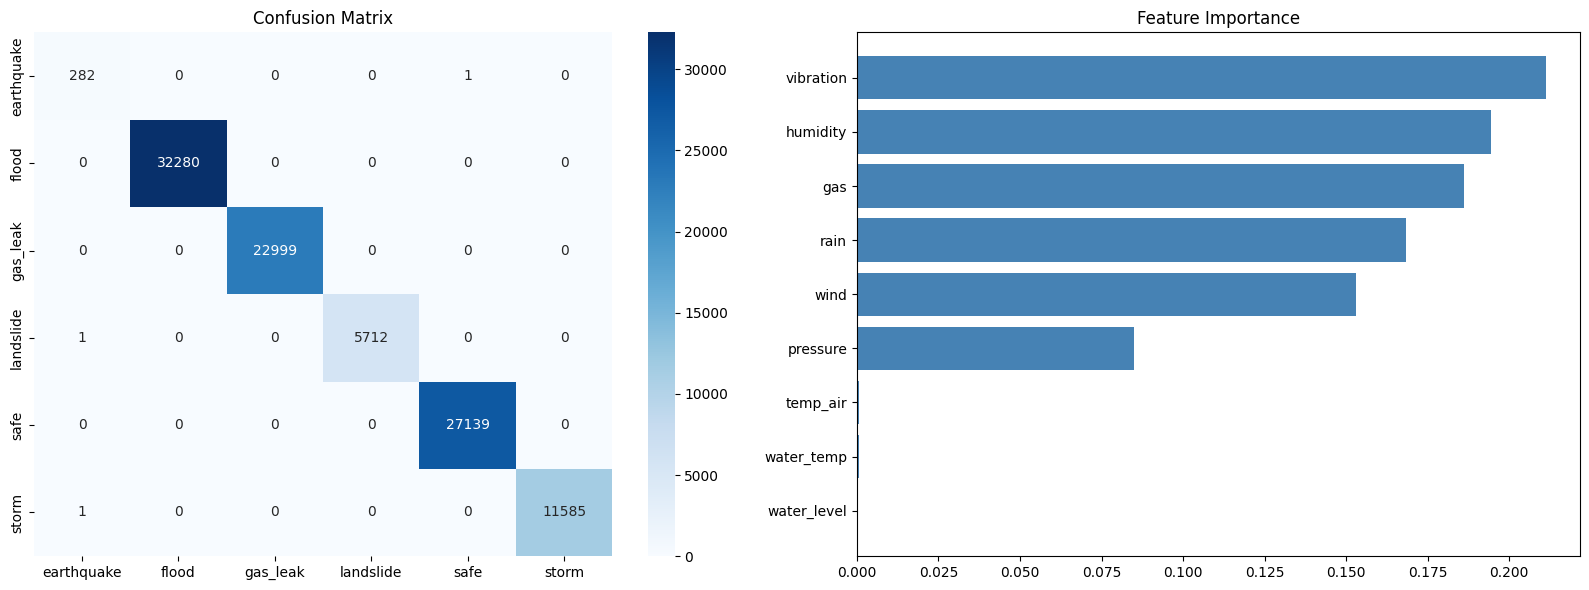

['scaler.pkl']

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

df = pd.read_csv('final_dataset.csv')

sensor_cols = [
    'temp_air', 'humidity', 'pressure', 'wind',
    'rain', 'gas', 'vibration', 'water_level', 'water_temp'
]

for col in sensor_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

X = df[sensor_cols]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')

plt.subplot(1, 2, 2)
importances = model.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), [sensor_cols[i] for i in indices])
plt.title('Feature Importance')

plt.tight_layout()
plt.show()

def get_top_3(input_data):
    input_scaled = scaler.transform([input_data])
    probs = model.predict_proba(input_scaled)[0]
    top_indices = probs.argsort()[-3:][::-1]
    results = []
    for idx in top_indices:
        results.append((model.classes_[idx], probs[idx]))
    return results

joblib.dump(model, 'disaster_model.pkl')
joblib.dump(scaler, 'scaler.pkl')